In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
import io
import os
import sys
from PIL import Image
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from microfilm.microplot import microshow

In [3]:
# with this peice of code, it will recognize the custom modules
project_root = "/Users/cgeyskens/Documents/code/phd/image-analysis/synapse-counting"
sys.path.append(project_root)

# custom modules
from synapse_counting import metadata, preprocessing, calc_synaptic_metrics

# input folder
input_folder = "/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_images"

# get a list of files in that input_folder
file_list = os.listdir(input_folder)
print(file_list)

['CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SO.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SR.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SL.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SO.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SR.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_DG_Hilus.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_DG_ML.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_VCAM1-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_VCAM1-g

In [ ]:
file = "/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_images/CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi"
from skimage.io import imsave
# extract metadata for pixel_size parameter in overlap_um2_coloc
pixel_size_um, _ , image_size_um = metadata.extract_metadata(file_path)
# preprocessing for puncta_metrics
pre, post = preprocessing.extract_and_split(file_path, presynapse_channel = 0, postsynapse_channel = 1)
p = preprocessing.ImagePreprocessing( 
            include_rolling_ball = True, radius = 10, # rolling ball parameters
            include_clahe = True, clip_limit = 0.005, kernel_size = 150, nbins = 265, # CLAHE parameters
            include_tophat = True, element_size = 5, # tophat parameters
            include_blur = True, sigma = 1, preserve_range = True # gaussian blur filters
            )


pre_1, post_1 = p.preprocess(pre, post)
# getting the data
presynapse_image_mfi, postsynapse_image_mfi = calc_synaptic_metrics.mfi_synapse(pre, post)
puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(pre_1, 
                                                                                        post_1, 
                                                                                        image_size_um, 
                                                                                        pixel_size_um, 
                                                                                        threshold_algorithm = "triangle")

imsave('pre_processed_image.png', pre_1)

CA1_SLM.czi


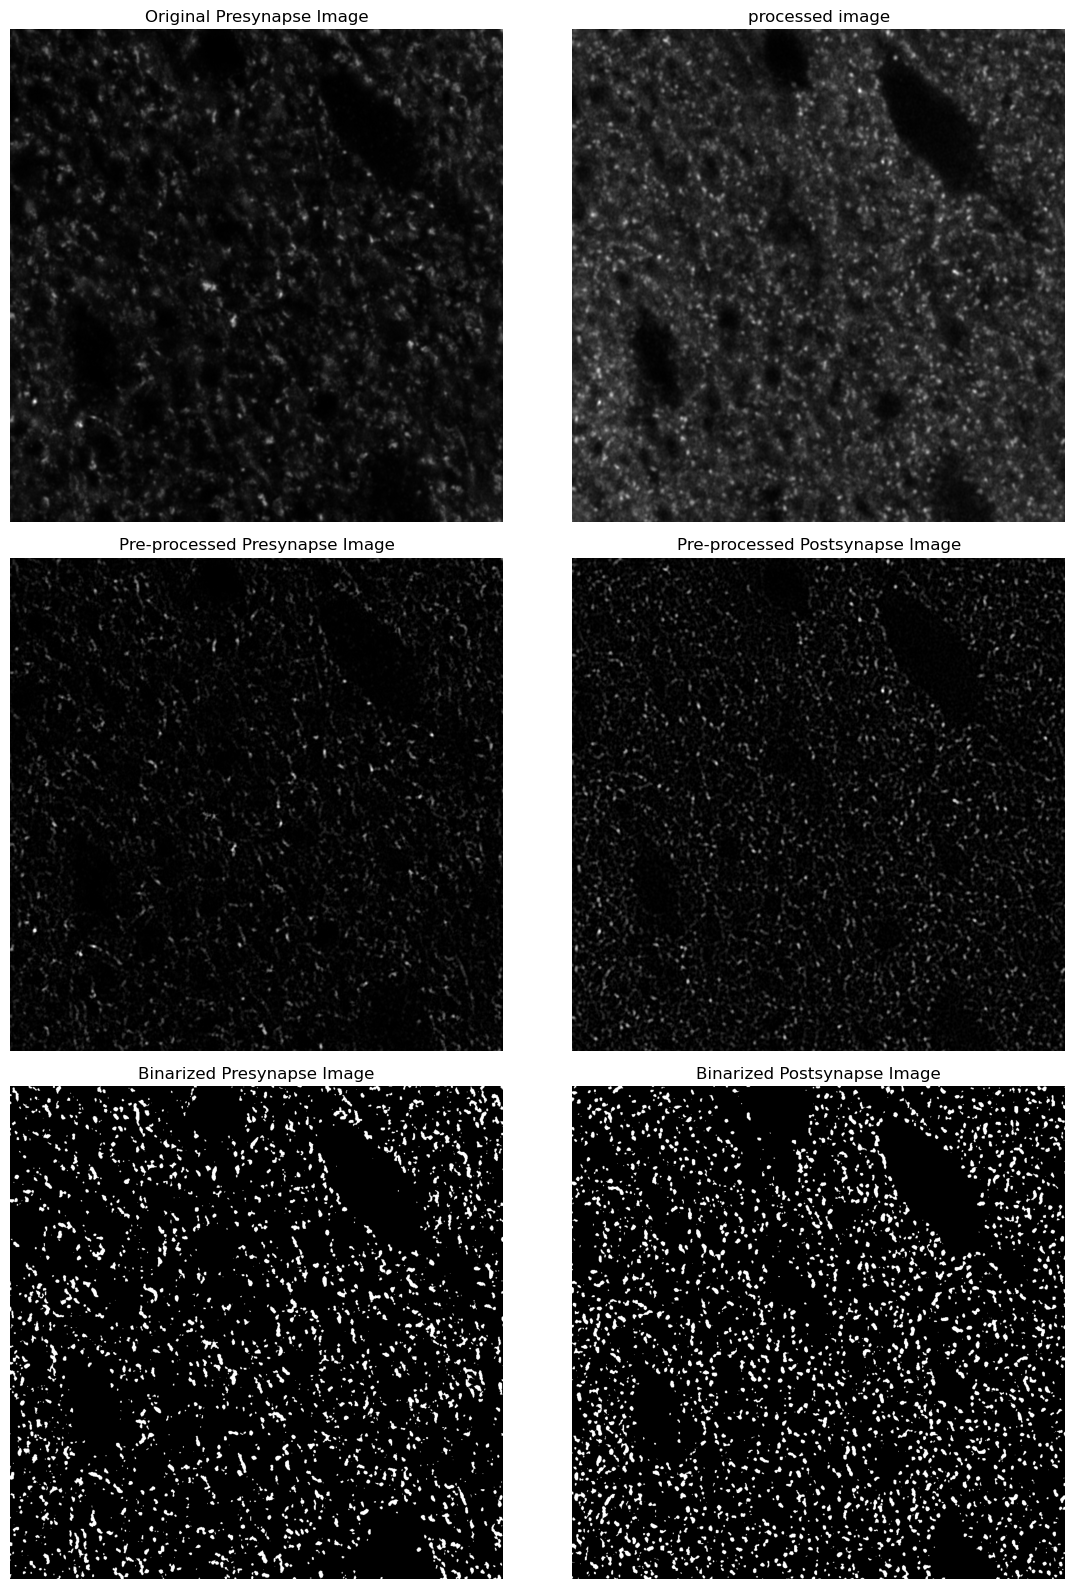

CA1_SO.czi


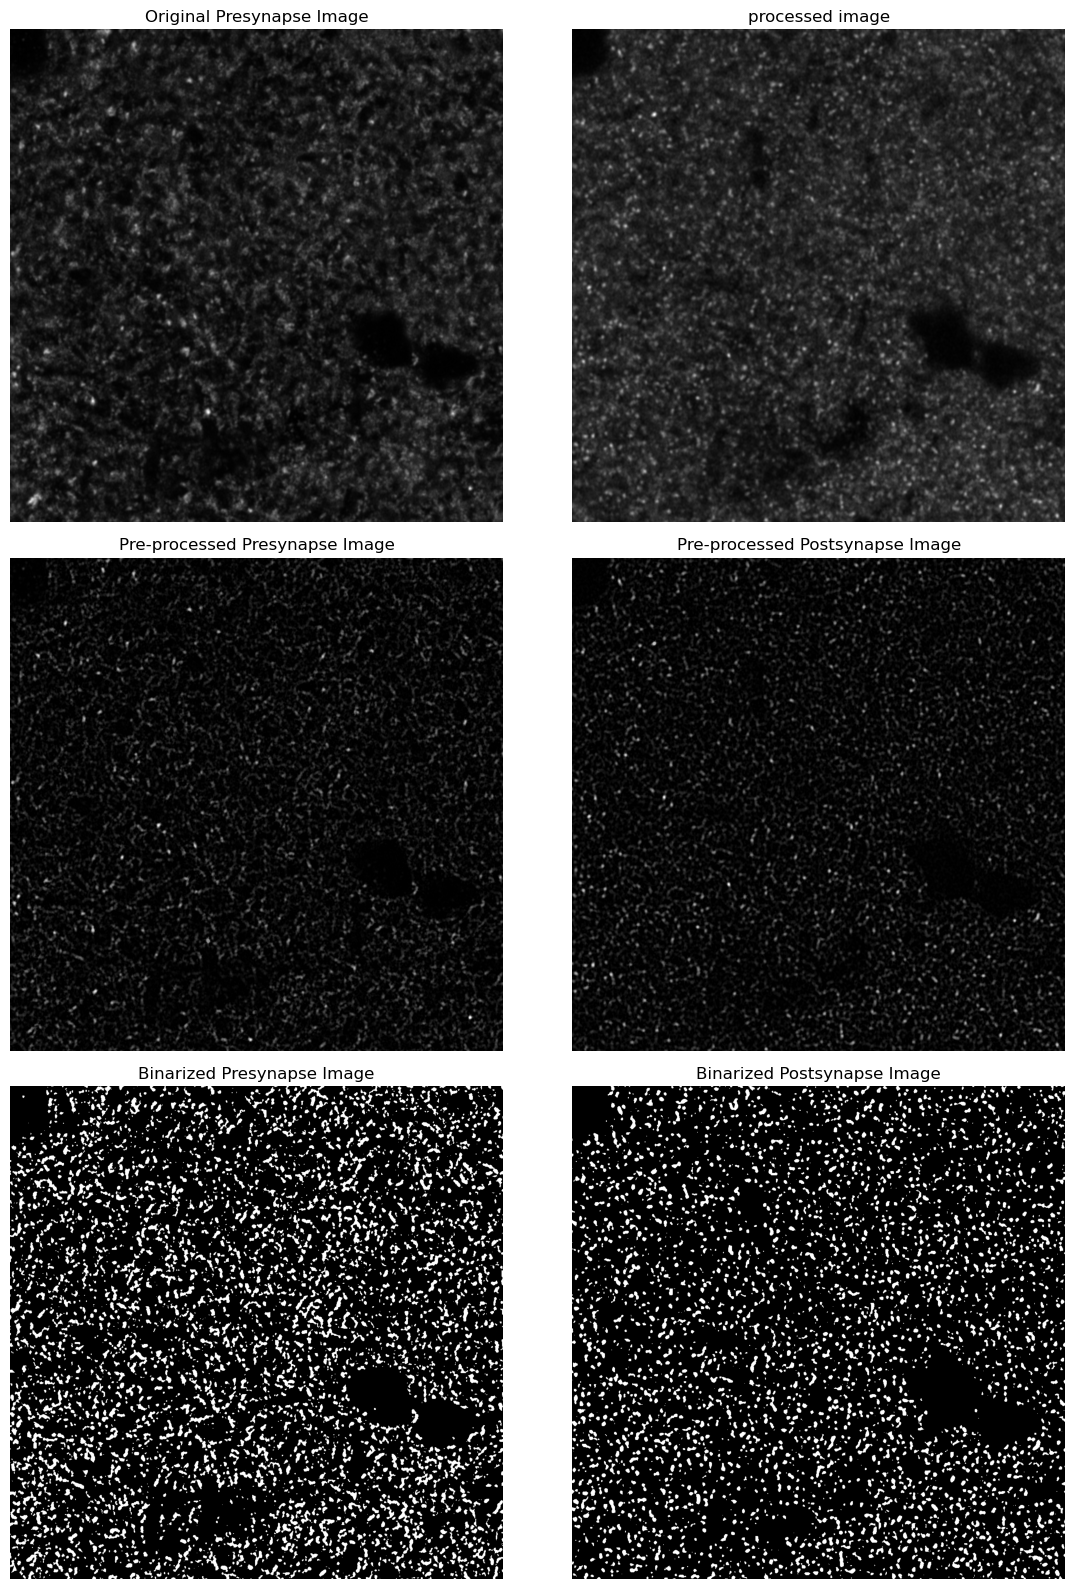

CA1_SR.czi


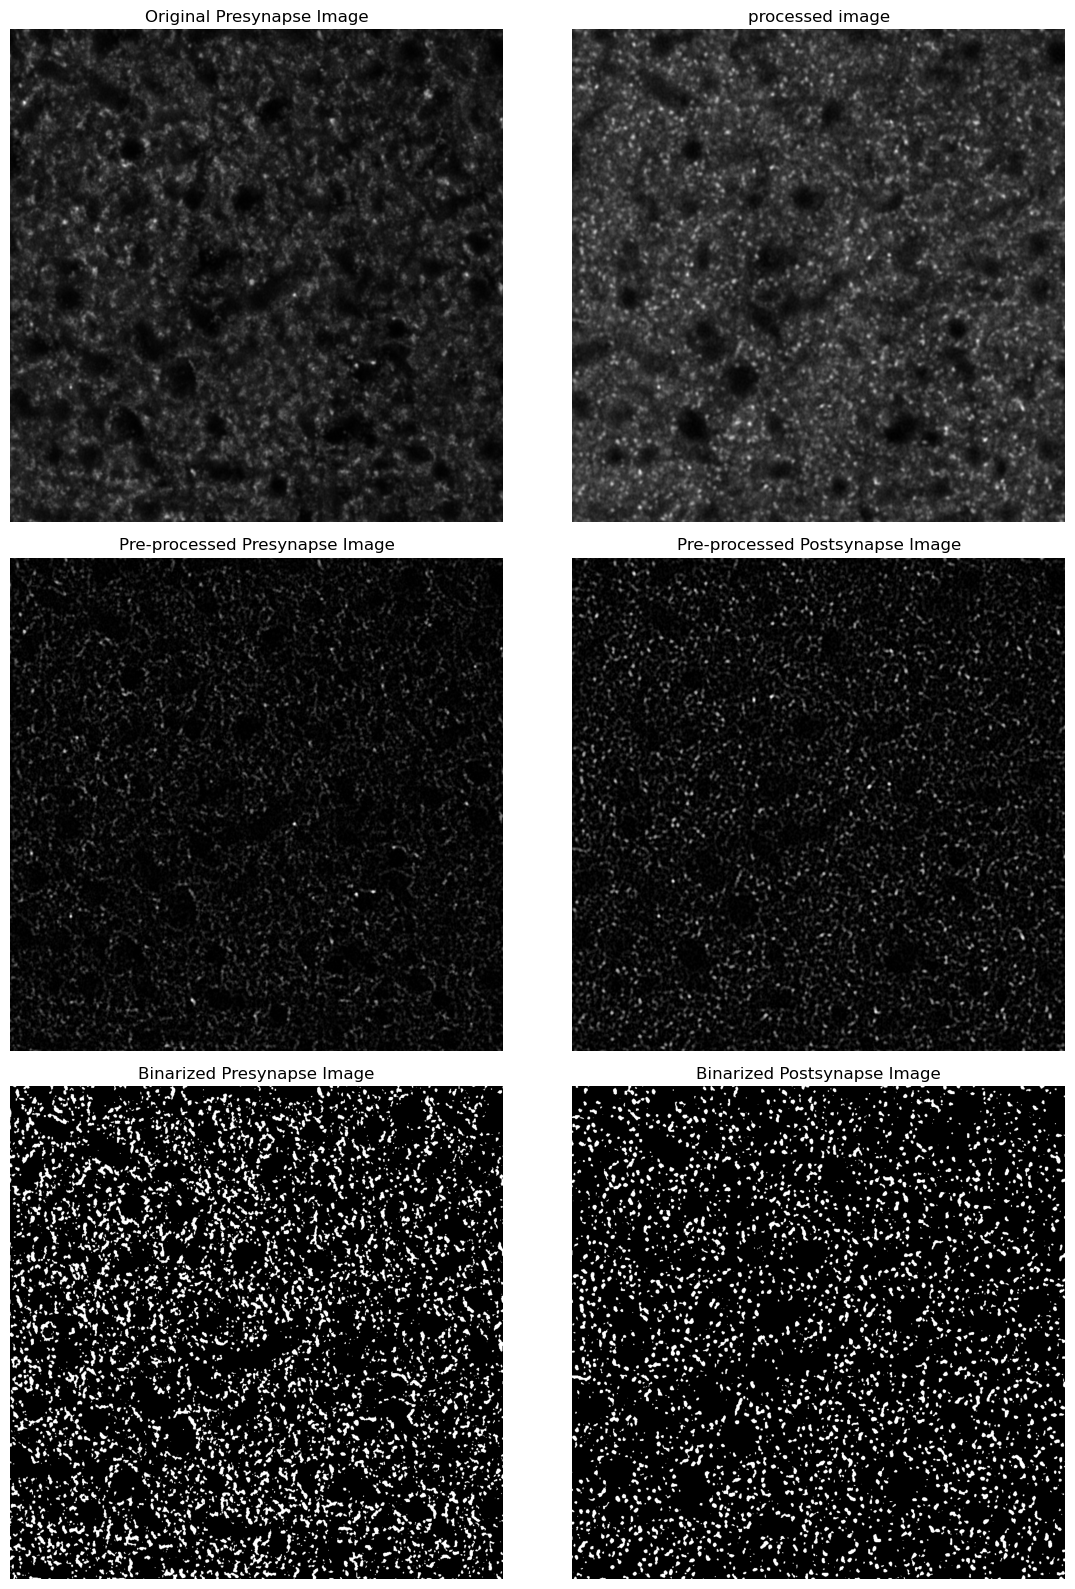

CA3_SL.czi
big synapse


KeyboardInterrupt: 

In [11]:
big_synapses = {"CA3_SL.czi", "DG_Hilus.czi"}

for filename in file_list:
    file_path = os.path.join(input_folder, filename)
    parts = filename.split('_')[-2:]
    result = "_".join(parts)
    print(result)
    if result in big_synapses:
        print("big synapse")
        # extract metadata for pixel_size parameter in overlap_um2_coloc
        pixel_size_um, _ , image_size_um = metadata.extract_metadata(file_path)
        # preprocessing for puncta_metrics
        pre, post = preprocessing.extract_and_split(file_path, presynapse_channel = 0, postsynapse_channel = 1)
        p = preprocessing.ImagePreprocessing( 
                 include_rolling_ball = True, radius = 5, # rolling ball parameters
                 include_clahe = True, clip_limit = 0.005, kernel_size = 150, nbins = 265, # CLAHE parameters
                 include_tophat = True, element_size = 5, # tophat parameters
                 include_blur = True, sigma = 1, preserve_range = True # gaussian blur filters
                 )
        
        
        pre_1, post_1 = p.preprocess(pre, post)
        # getting the data
        presynapse_image_mfi, postsynapse_image_mfi = calc_synaptic_metrics.mfi_synapse(pre, post)
        puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(pre_1, 
                                                                                             post_1, 
                                                                                             image_size_um, 
                                                                                             pixel_size_um, 
                                                                                             threshold_algorithm = "isodata")
        # Display the pre-processed and post-processed images
        fig, axes = plt.subplots(3, 2, figsize=(12, 16))
        
        axes[0, 0].imshow(pre, cmap='gray')
        axes[0, 0].set_title('Original Presynapse Image')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(post, cmap='gray')
        axes[0, 1].set_title('processed image')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(pre_1, cmap='gray')
        axes[1, 0].set_title('Pre-processed Presynapse Image')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(post_1, cmap='gray')
        axes[1, 1].set_title('Pre-processed Postsynapse Image')
        axes[1, 1].axis('off')

        axes[2, 0].imshow(pre_processed, cmap='gray')
        axes[2, 0].set_title('Binarized Presynapse Image')
        axes[2, 0].axis('off')
        
        axes[2, 1].imshow(post_processed, cmap='gray')
        axes[2, 1].set_title('Binarized Postsynapse Image')
        axes[2, 1].axis('off')
        
        plt.tight_layout()
        plt.show()

        # Save the pre_processed image
        pre_processed_filename = os.path.join(input_folder, f"pre_processed_{filename}.png")
        plt.imshow(pre_processed, cmap='gray')
        plt.axis('off')
        plt.savefig(pre_processed_filename, bbox_inches='tight', pad_inches=0)
        plt.close()
    
    else:
                # extract metadata for pixel_size parameter in overlap_um2_coloc
        pixel_size_um, _ , image_size_um = metadata.extract_metadata(file_path)
        # preprocessing for puncta_metrics
        pre, post = preprocessing.extract_and_split(file_path, presynapse_channel = 0, postsynapse_channel = 1)
        p = preprocessing.ImagePreprocessing(
                 include_rolling_ball = True, radius = 10, # rolling ball parameters
                 include_clahe = True, clip_limit = 0.005, kernel_size = 150, nbins = 265, # CLAHE parameters
                 include_tophat = True, element_size = 5, # tophat parameters
                 include_blur = False, sigma = 4, preserve_range = True # gaussian blur filters
                 )
        pre_1, post_1 = p.preprocess(pre, post)
        # getting the data
        presynapse_image_mfi, postsynapse_image_mfi = calc_synaptic_metrics.mfi_synapse(pre, post)
        puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(pre_1, 
                                                                                             post_1, 
                                                                                             image_size_um, 
                                                                                             pixel_size_um, 
                                                                                             threshold_algorithm = "isodata")
        
        # Display the pre-processed and post-processed images
        fig, axes = plt.subplots(3, 2, figsize=(12, 16))
        
        axes[0, 0].imshow(pre, cmap='gray')
        axes[0, 0].set_title('Original Presynapse Image')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(post, cmap='gray')
        axes[0, 1].set_title('processed image')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(pre_1, cmap='gray')
        axes[1, 0].set_title('Pre-processed Presynapse Image')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(post_1, cmap='gray')
        axes[1, 1].set_title('Pre-processed Postsynapse Image')
        axes[1, 1].axis('off')

        axes[2, 0].imshow(pre_processed, cmap='gray')
        axes[2, 0].set_title('Binarized Presynapse Image')
        axes[2, 0].axis('off')
        
        axes[2, 1].imshow(post_processed, cmap='gray')
        axes[2, 1].set_title('Binarized Postsynapse Image')
        axes[2, 1].axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
from skimage import measure, filters

file = "/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_images/CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi"
pixel_size_um, _ , image_size_um = metadata.extract_metadata(file_path)
pre, post = preprocessing.extract_and_split(file_path, presynapse_channel = 0, postsynapse_channel = 1)
p = preprocessing.ImagePreprocessing(
            include_rolling_ball = True, radius = 10, # rolling ball parameters
            include_clahe = True, clip_limit = 0.005, kernel_size = 150, nbins = 265, # CLAHE parameters
            include_tophat = True, element_size = 5, # tophat parameters
            include_blur = True, sigma = 1, preserve_range = True # gaussian blur filters
            )
pre_1, post_1 = p.preprocess(pre, post)

puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(pre_1, 
                                                                                        post_1, 
                                                                                        image_size_um, 
                                                                                        pixel_size_um, 
                                                                                        threshold_algorithm = "triangle")
plt.imshow(post_processed)
# presynapse_threshold = filters.threshold_otsu(pre_1)
# presynapse_thresholded = pre_1 > presynapse_threshold
# plt.imshow(presynapse_thresholded, cmap='gray')

In [ ]:

import os
import metadata
import preprocessing
import calc_synaptic_metrics

for filename in file_list:
    file_path = os.path.join(input_folder, filename)
    parts = filename.split('_')[-2:]
    result = "_".join(parts)
    print(result)
    
    if result == "CA3_SL.czi" or result == "DG_Hilus.czi":  # Fixed condition check
        # extract metadata for pixel_size parameter in overlap_um2_coloc
        pixel_size_um, _, image_size_um = metadata.extract_metadata(file_path)
        # preprocessing for puncta_metrics
        pre, post = preprocessing.extract_and_split(file_path, presynapse_channel=0, postsynapse_channel=1)
        p = preprocessing.ImagePreprocessing( 
            include_rolling_ball=True, radius=10,  # rolling ball parameters
            include_clahe=True, clip_limit=0.005, kernel_size=150, nbins=265,  # CLAHE parameters
            include_tophat=True, element_size=5,  # tophat parameters
            include_blur=True, sigma=1, preserve_range=True  # gaussian blur filters
        )

        pre_1, post_1 = p.preprocess(pre, post)
        # getting the data
        presynapse_image_mfi, postsynapse_image_mfi = calc_synaptic_metrics.mfi_synapse(pre, post)
        puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(
            pre_1, post_1, image_size_um, pixel_size_um, threshold_algorithm="triangle")
        
        # Display the pre-processed and post-processed images
        microshow.imshow(pre, title='Original Presynapse Image')
        microshow.imshow(post, title='Processed Image')
        microshow.imshow(pre_1, title='Pre-processed Presynapse Image')
        microshow.imshow(post_1, title='Pre-processed Postsynapse Image')
        microshow.imshow(pre_processed, title='Binarized Presynapse Image')
        microshow.imshow(post_processed, title='Binarized Postsynapse Image')
        microshow.show()
    
    else:
        # extract metadata for pixel_size parameter in overlap_um2_coloc
        pixel_size_um, _, image_size_um = metadata.extract_metadata(file_path)
        # preprocessing for puncta_metrics
        pre, post = preprocessing.extract_and_split(file_path, presynapse_channel=0, postsynapse_channel=1)
        p = preprocessing.ImagePreprocessing(
            include_rolling_ball=True, radius=10,  # rolling ball parameters
            include_clahe=True, clip_limit=0.005, kernel_size=150, nbins=265,  # CLAHE parameters
            include_tophat=True, element_size=5,  # tophat parameters
            include_blur=True, sigma=1, preserve_range=True  # gaussian blur filters
        )
        pre_1, post_1 = p.preprocess(pre, post)
        # getting the data
        presynapse_image_mfi, postsynapse_image_mfi = calc_synaptic_metrics.mfi_synapse(pre, post)
        puncta_results, pre_processed, post_processed = calc_synaptic_metrics.puncta_metrics(
            pre_1, post_1, image_size_um, pixel_size_um, threshold_algorithm="triangle")

        # Display the pre-processed and post-processed images
        microshow.imshow(pre, title='Original Presynapse Image')
        microshow.imshow(post, title='Processed Image')
        microshow.imshow(pre_1, title='Pre-processed Presynapse Image')
        microshow.imshow(post_1, title='Pre-processed Postsynapse Image')
        microshow.imshow(pre_processed, title='Binarized Presynapse Image')
        microshow.imshow(post_processed, title='Binarized Postsynapse Image')
        microshow.show()
